In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.interpolate import interp1d
from scipy.ndimage import label
import optuna
from collections import deque
from scripts.loader import * 
from scripts.processing import *
import matplotlib.pyplot as plt
import seaborn as sns
import math
%matplotlib widget

# Load data

In [2]:
exp_data_folder = Path("../data")
dataset = DatasetGrail(exp_data_folder, "../data/config.xlsx")
dataset = dataset.get_subset(task=["walking"])
index = dataset.create_index()
index.head()

,id,speed,measurement,task
0,S01,0.0,static,static
1,S01,1.0,walking1,walking
2,S01,1.6,walking2,walking
3,S01,1.2,walking3,walking
4,S01,1.8,walking4,walking


In [9]:
participants = np.unique(dataset.index.id)
speeds = np.unique(dataset.index.speed)

In [10]:
speeds

array([1. , 1.2, 1.4, 1.6, 1.8])

In [16]:
data = np.zeros((15, 5, 6, 100))
durations = np.zeros((15,5))

In [17]:
for i, p in enumerate(participants):
    print('participant ', i)
    for j, s in enumerate(speeds):
        print(s)
        trial = dataset.get_subset(id=p, speed=s)
    

        cycles, dur = get_data(trial)
        dur = np.round(dur, 3)

        data[i, j, 0, :] = cycles.FxL
        data[i, j, 1, :] = cycles.FyL
        data[i, j, 2, :] = cycles.FxR
        data[i, j, 3, :] = cycles.FyR
        data[i, j, 4, :] = cycles.speedL
        data[i, j, 5, :] = cycles.speedR
        
        durations[i,j] = dur

participant  0
1.0
1.2
1.4
1.6
1.8
participant  1
1.0
1.2
1.4
1.6
1.8
participant  2
1.0
1.2
1.4
1.6
1.8
participant  3
1.0
1.2
1.4
1.6
1.8
participant  4
1.0
1.2
1.4
1.6
1.8
participant  5
1.0
1.2
1.4
1.6
1.8
participant  6
1.0
1.2
1.4
1.6
1.8
participant  7
1.0
1.2
1.4
1.6
1.8
participant  8
1.0
1.2
1.4
1.6
1.8
participant  9
1.0
1.2
1.4
1.6
1.8
participant  10
1.0
1.2
1.4
1.6
1.8
participant  11
1.0
1.2
1.4
1.6
1.8
participant  12
1.0
1.2
1.4
1.6
1.8
participant  13
1.0
1.2
1.4
1.6
1.8
participant  14
1.0
1.2
1.4
1.6
1.8


In [84]:
participants = ["P" + str(i) for i in range(1,16)]
speeds = [1.0, 1.2, 1.4, 1.6, 1.8]
channels = ["Fx1", "Fy1", "Fx2", "Fy2", "speed1", "speed2"] 
nodes = np.arange(100)

In [85]:
# Reshape from (15, 5, 6, 100) -> (15*5*100, 6)
values = data.transpose(0, 1, 3, 2).reshape(-1, len(channels))

# Create DataFrame
df = pd.DataFrame(values, columns=channels)

# Add identifiers
df.insert(
    0,
    "participant",
    np.repeat(participants, len(speeds) * len(nodes))
)
df.insert(
    1,
    "speed",
    np.tile(np.repeat(speeds, len(nodes)), len(participants))
)
df.insert(
    2,
    "node",
    np.tile(nodes, len(participants) * len(speeds))
)

# Add durations
df["duration"] = np.repeat(durations.ravel(), len(nodes))


mask = df["Fy1"] < 0
df.loc[mask, ["Fx1", "Fy1"]] = 0

# Right foot
mask = df["Fy2"] < 0
df.loc[mask, ["Fx2", "Fy2"]] = 0

In [86]:
df

,participant,speed,node,Fx1,Fy1,Fx2,Fy2,speed1,speed2,duration
0,P1,1.0,0,6.778199,10.836345,81.390185,684.700194,0.999595,1.002124,1.226
1,P1,1.0,1,10.082935,40.765163,90.397159,675.404113,0.999647,1.002747,1.226
2,P1,1.0,2,9.359903,88.881009,99.532026,658.978736,0.999695,1.003120,1.226
3,P1,1.0,3,-0.343441,151.677292,107.787986,633.433005,0.999182,1.003796,1.226
4,P1,1.0,4,-19.018211,223.829338,114.335766,596.942466,0.999312,1.005103,1.226
...,...,...,...,...,...,...,...,...,...,...
7495,P15,1.8,95,0.000000,0.000000,127.509068,806.045908,1.799701,1.802631,0.884
7496,P15,1.8,96,0.000000,0.000000,140.232126,825.018079,1.799697,1.803403,0.884
7497,P15,1.8,97,0.000000,0.000000,152.528644,833.738588,1.799627,1.804010,0.884
7498,P15,1.8,98,0.000000,0.000000,164.020446,829.710223,1.799725,1.804228,0.884


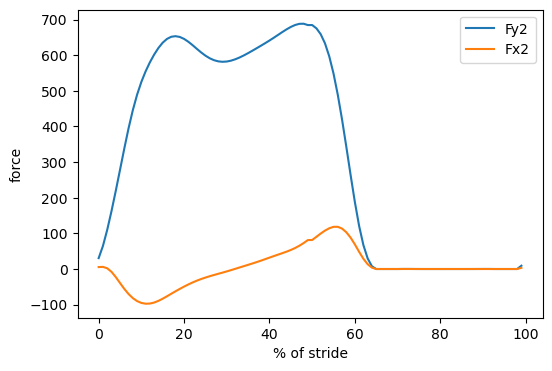

In [88]:
p = "P1"
s = 1.0

tmp = df[(df["participant"] == p) & (df["speed"] == s)].copy()

shift = 50

plt.figure(figsize=(6, 4))
plt.plot(tmp["node"], np.roll(tmp["Fy2"].values, shift), label="Fy2")
plt.plot(tmp["node"], np.roll(tmp["Fx2"].values, shift), label="Fx2")


#plt.plot(fx_shifted, label="Fx2")
plt.xlabel("% of stride")
plt.ylabel("force")
plt.legend()
plt.show()


In [89]:
def fix_boundary_poly(x, n=3):
    y = x.copy()

    x_fit = np.r_[np.arange(100 - n, 100), np.arange(100, 100 + n)]
    y_fit = np.r_[y[-n:], y[:n]]

    poly = np.poly1d(np.polyfit(x_fit, y_fit, deg=2))

    y[-2] = poly(98)
    y[-1] = poly(99)
    y[0] = poly(100)

    return y

In [90]:
from scipy.signal import savgol_filter

channels = ["Fx1", "Fy1", "Fx2", "Fy2"]

def filter_periodic(x, window_length=7, polyorder=2):
    return savgol_filter(
        x,
        window_length=window_length,
        polyorder=polyorder,
        mode="wrap"   # treats the signal as periodic
    )

df_fixed = df.copy()

for ch in channels:
    df_fixed[ch] = (
        df_filtered.groupby(["participant", "speed"])[ch]
                   .transform(lambda x: filter_periodic(x, window_length=7, polyorder=2)))

In [91]:
df_fixed

,participant,speed,node,Fx1,Fy1,Fx2,Fy2,speed1,speed2,duration
0,P1,1.0,0,8.445952,16.606416,84.292561,683.436634,0.999595,1.002124,1.226
1,P1,1.0,1,10.701998,43.977805,91.000783,674.922127,0.999647,1.002747,1.226
2,P1,1.0,2,7.464868,88.501536,98.753535,659.243907,0.999695,1.003120,1.226
3,P1,1.0,3,-1.990386,151.782960,107.826303,633.068394,0.999182,1.003796,1.226
4,P1,1.0,4,-19.211724,223.867082,114.464660,596.462114,0.999312,1.005103,1.226
...,...,...,...,...,...,...,...,...,...,...
7495,P15,1.8,95,0.000000,0.000000,127.453373,806.150529,1.799701,1.802631,0.884
7496,P15,1.8,96,-0.785669,-1.151323,140.377722,824.933473,1.799697,1.803403,0.884
7497,P15,1.8,97,0.388230,0.577379,153.302237,830.039770,1.799627,1.804010,0.884
7498,P15,1.8,98,2.602310,-0.849329,163.432216,829.615400,1.799725,1.804228,0.884


In [92]:
df.to_csv("gait_data.csv", index=False)